# Loading and Exploring ODMR Data with QDMpy

This notebook demonstrates how to load and explore ODMR (Optically Detected Magnetic Resonance) data from a QDM (Quantum Diamond Microscope) measurement using QDMpy.

We use the `MIL2_FOV1` test dataset, which contains:
- Two MATLAB files (`run_00000.mat`, `run_00001.mat`) with ODMR spectra at two field polarities
- LED and laser reference images
- Acquisition metadata in header files

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from QDMpy.odmr import ODMR, ODMRData, b111_from_dip_positions
from QDMpy.odmr.io import MatlabLoader
from QDMpy.odmr.processors import BinningProcessor, FluorescenceCorrectionProcessor, NormalizationProcessor
from QDMpy.fitting import FitManager

2026-02-21 07:25:25.670 | INFO     | QDMpy.fitting.models:register:345 - Registered model: ESR14N
2026-02-21 07:25:25.671 | INFO     | QDMpy.fitting.models:register:345 - Registered model: ESR15N
2026-02-21 07:25:25.672 | INFO     | QDMpy.fitting.models:register:345 - Registered model: ESRSINGLE


## 1. Load raw ODMR data

The `MatlabLoader` reads `run_*.mat` files from the data folder. Each file corresponds to
one field polarity and contains two image stacks (low-field and high-field frequency ranges)
with 51 frequency steps across a 1920 × 1200 pixel field of view.

In [2]:
DATA_FOLDER = Path.home() / "git" / "QDMpy" / "tests" / "data" / "MIL2_FOV1"

loader = MatlabLoader(data_folder=str(DATA_FOLDER))
odmr_data = ODMRData.from_loader(loader)

2026-02-21 07:25:25.683 | INFO     | QDMpy.odmr.data:from_loader:133 - Loading ODMR data using loader: MatlabLoader
2026-02-21 07:25:25.685 | INFO     | QDMpy.odmr.io:load:82 - Found 2 MATLAB file(s) in /home/mike/git/QDMpy/tests/data/MIL2_FOV1
2026-02-21 07:25:38.449 | INFO     | QDMpy.odmr.io:load:151 - MATLAB data loaded in 12.76s — shape (2, 2, 1200, 1920, 51)


## 2. Inspect the xarray DataArray

The data is stored as a 5D `xarray.DataArray` with named dimensions:
- `polarity` — field polarity (one per `.mat` file)
- `freq_range` — low-field vs high-field frequency band
- `y`, `x` — spatial pixel coordinates
- `freq_idx` — frequency sweep index

Actual frequency values in GHz are stored as a non-dimension coordinate `freq_ghz`.

In [3]:
odmr_data.data

<xarray.DataArray (polarity: 2, freq_range: 2, y: 1200, x: 1920, freq_idx: 51)> Size: 4GB
array([[[[[0.98293855, 0.98255049, 0.98237327, ..., 0.98234963,
           0.98190615, 0.98211046],
          [0.98270634, 0.9821743 , 0.98295283, ..., 0.98220875,
           0.98200447, 0.98248516],
          [0.98223778, 0.98189767, 0.9822132 , ..., 0.98224757,
           0.98234219, 0.98250858],
          ...,
          [0.98240601, 0.98156733, 0.98299475, ..., 0.98281256,
           0.98164887, 0.9822598 ],
          [0.98247129, 0.98305621, 0.98281471, ..., 0.98210023,
           0.98312218, 0.98267866],
          [0.98312303, 0.9836576 , 0.98375951, ..., 0.98210867,
           0.9822048 , 0.98134222]],

         [[0.98259217, 0.98273997, 0.98220567, ..., 0.98191149,
           0.98259238, 0.98193482],
          [0.98251943, 0.98227933, 0.98275746, ..., 0.98306639,
           0.98248483, 0.98169869],
          [0.9823511 , 0.98279712, 0.98267526, ..., 0.98187718,
           0.98172122, 0.98201717],
...
          [0.98365185, 0.98290684, 0.98329903, ..., 0.98404008,
           0.98384045, 0.98329959],
          [0.9836041 , 0.98295623, 0.98324533, ..., 0.98348643,
           0.98411886, 0.98288471],
          [0.98349064, 0.98387511, 0.98299548, ..., 0.98208091,
           0.98353712, 0.98422768]],

         [[0.98360551, 0.98362786, 0.98303198, ..., 0.98314939,
           0.98243026, 0.9838323 ],
          [0.98316162, 0.98255554, 0.98296702, ..., 0.98343   ,
           0.98354246, 0.98345199],
          [0.98269289, 0.98314271, 0.98319887, ..., 0.9834423 ,
           0.98376867, 0.98339341],
          ...,
          [0.98234501, 0.98372533, 0.98355091, ..., 0.98248481,
           0.98325733, 0.98345278],
          [0.98283755, 0.98265919, 0.98354431, ..., 0.98270771,
           0.98310156, 0.98252928],
          [0.98275814, 0.98259609, 0.98328594, ..., 0.98352295,
           0.98370178, 0.98396743]]]]], shape=(2, 2, 1200, 1920, 51))
Coordinates:
  * polarity    (polarity) <U3 24B 'neg' 'pos'
  * freq_range  (freq_range) <U4 32B 'low' 'high'
    freq_ghz    (freq_range, freq_idx) float64 816B 2.838 2.839 ... 2.902 2.902
Dimensions without coordinates: y, x, freq_idx

In [4]:
# Frequency values for each range (in GHz)
freq_ghz = odmr_data.data.coords["freq_ghz"].values  # shape (n_frange, n_freq)
frange_labels = list(odmr_data.data.coords["freq_range"].values)

print("Frequency ranges:")
for label, freqs in zip(frange_labels, freq_ghz):
    step_mhz = (freqs[-1] - freqs[0]) / (len(freqs) - 1) * 1000
    print(f"  {label}: {freqs[0]:.4f} – {freqs[-1]:.4f} GHz  "
          f"({len(freqs)} steps, Δf ≈ {step_mhz:.2f} MHz)")

Frequency ranges:
  low: 2.8383 – 2.8513 GHz  (51 steps, Δf ≈ 0.26 MHz)
  high: 2.8894 – 2.9024 GHz  (51 steps, Δf ≈ 0.26 MHz)


## 3. Load reference images

The dataset includes LED (white light) and laser images used for alignment and fluorescence correction.

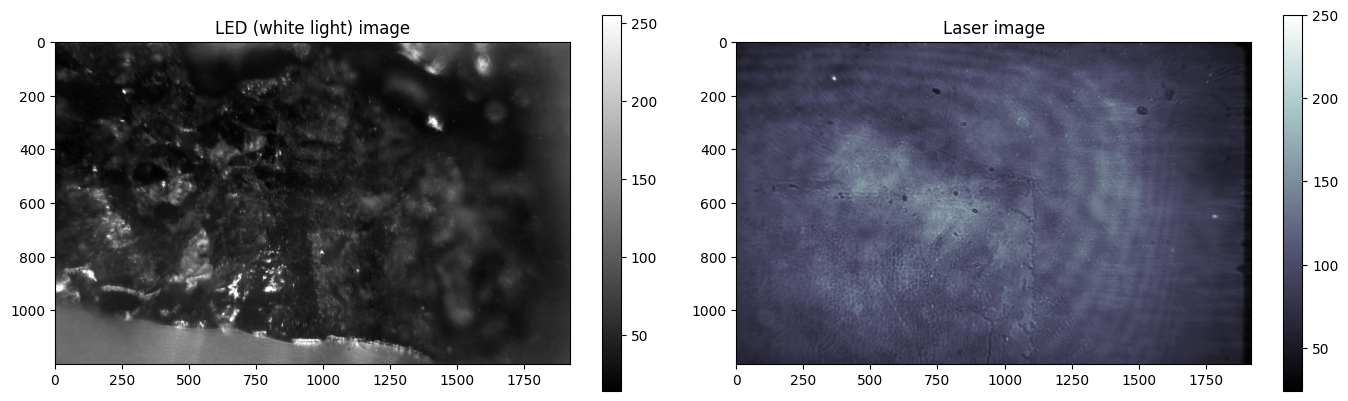

In [5]:
led_image = np.loadtxt(DATA_FOLDER / "LED.csv")
laser_image = np.loadtxt(DATA_FOLDER / "laser.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(led_image, cmap="gray")
axes[0].set_title("LED (white light) image")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(laser_image, cmap="bone")
axes[1].set_title("Laser image")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

## 4. Visualize mean ODMR spectra

Before any processing, let's look at the spatially-averaged ODMR spectra for each
polarity and frequency range. Each spectrum should show Lorentzian dips at the
NV center resonance frequencies.

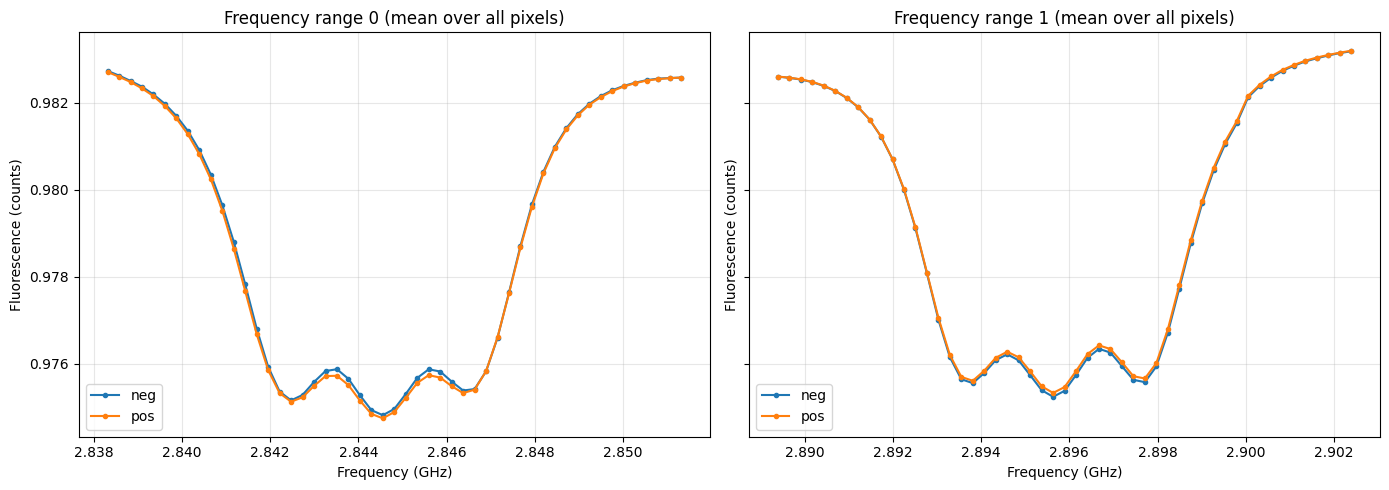

In [6]:
mean_spectra = odmr_data.data.mean(dim=["y", "x"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
pol_labels = list(odmr_data.data.coords["polarity"].values)

for i_frange in range(odmr_data.data.sizes["freq_range"]):
    ax = axes[i_frange]
    freqs = freq_ghz[i_frange]
    for i_pol in range(odmr_data.data.sizes["polarity"]):
        spectrum = mean_spectra.isel(polarity=i_pol, freq_range=i_frange).values
        ax.plot(freqs, spectrum, "o-", markersize=3, label=pol_labels[i_pol])
    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel("Fluorescence (counts)")
    ax.set_title(f"Frequency range {i_frange} (mean over all pixels)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Apply processing pipeline

QDMpy uses a processor pipeline to prepare data for fitting:
1. **Spatial binning** — reduces noise by averaging adjacent pixels (e.g. 4×4)
2. **Normalization** — divides each spectrum by its maximum value so dip depths represent contrast
3. **Fluorescence correction** — subtracts spatially-varying background fluorescence

In [7]:
odmr = ODMR(odmr_data)

odmr.processor_manager.add_processor(BinningProcessor(bin_factor=4))
odmr.processor_manager.add_processor(NormalizationProcessor(method="max"))
odmr.processor_manager.add_processor(FluorescenceCorrectionProcessor())
odmr.process_data()

2026-02-21 07:25:41.185 | INFO     | QDMpy.odmr.manager:process_data:94 - Processing data.
2026-02-21 07:25:41.186 | INFO     | QDMpy.odmr.processors:process:285 - Starting processing pipeline.
2026-02-21 07:25:43.119 | INFO     | QDMpy.odmr.processors:process:120 - Applying fluorescence correction with factor: 0.2
2026-02-21 07:25:43.374 | INFO     | QDMpy.odmr.processors:analyze_fluorescence_effects:183 - Automatically selected pixel index: 23153
2026-02-21 07:25:43.522 | INFO     | QDMpy.odmr.processors:process:290 - Processing pipeline completed.


## 6. Compare raw vs processed spectra

After binning and normalization, the spectra are smoother and the dips are easier
to identify. The y-axis now represents normalized contrast (1 = baseline).

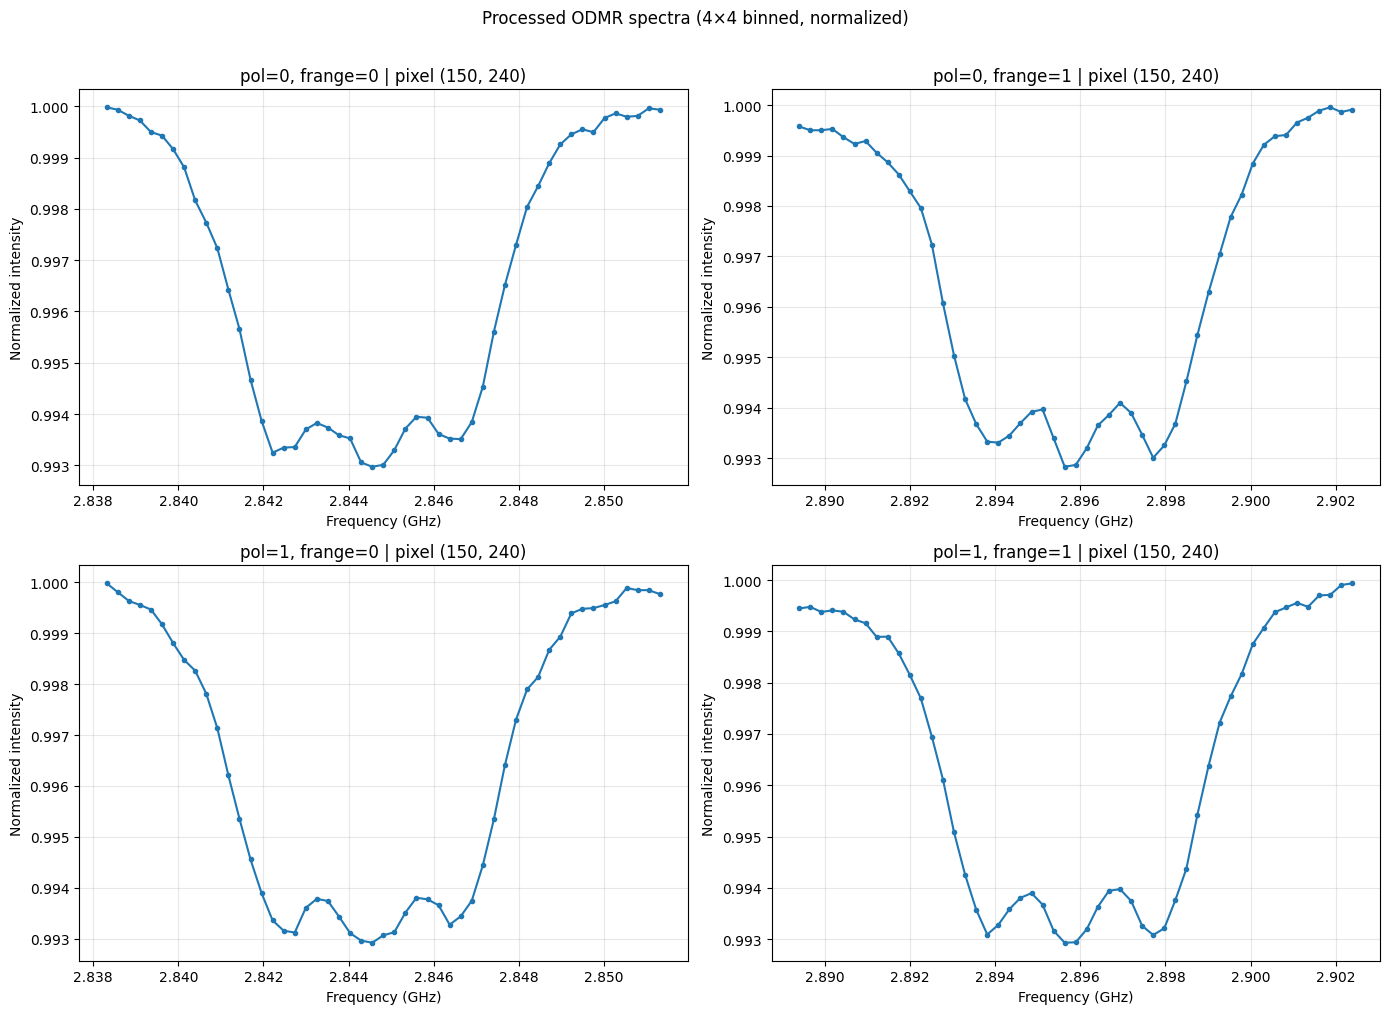

In [8]:
proc = odmr.processed_data

# Pick a pixel near the center of the binned image
cy, cx = proc.data.sizes["y"] // 2, proc.data.sizes["x"] // 2

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i_pol in range(proc.data.sizes["polarity"]):
    for i_frange in range(proc.data.sizes["freq_range"]):
        ax = axes[i_pol, i_frange]
        freqs = freq_ghz[i_frange]

        spectrum = proc.data.isel(polarity=i_pol, freq_range=i_frange, y=cy, x=cx).values
        ax.plot(freqs, spectrum, "o-", markersize=3, color="C0")

        ax.set_xlabel("Frequency (GHz)")
        ax.set_ylabel("Normalized intensity")
        ax.set_title(f"pol={i_pol}, frange={i_frange} | pixel ({cy}, {cx})")
        ax.grid(True, alpha=0.3)

plt.suptitle("Processed ODMR spectra (4×4 binned, normalized)", y=1.01)
plt.tight_layout()
plt.show()

## 7. Spatial maps of fluorescence and contrast

We can create spatial maps by reducing the frequency dimension. The mean gives an overall
fluorescence map, while the contrast (max − min along frequency) highlights regions with
strong ODMR signal.

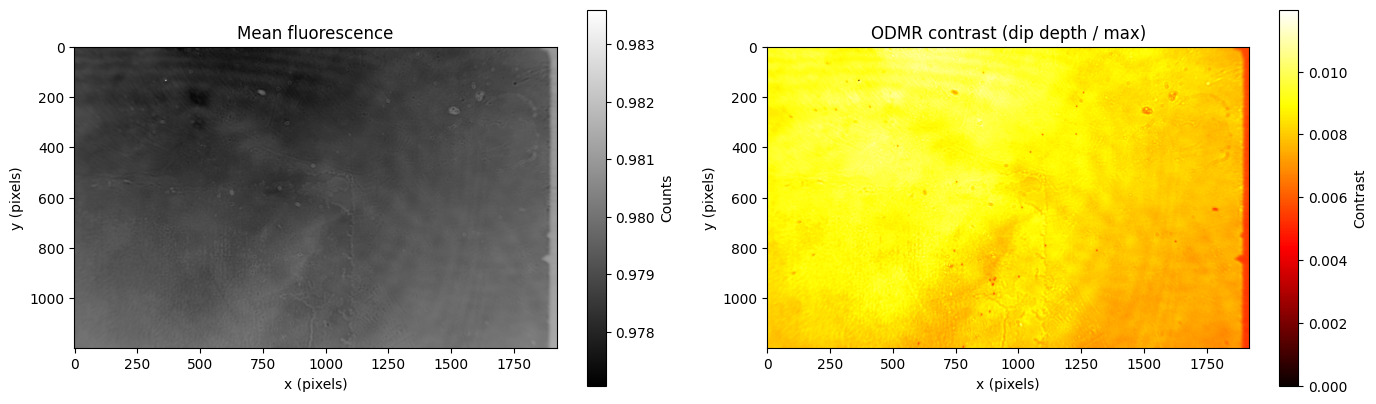

In [9]:
# Use raw (unbinned) data for full-resolution images
raw = odmr_data.data

# Fluorescence map: mean over frequency, averaged over polarities and ranges
fluorescence = raw.mean(dim=["polarity", "freq_range", "freq_idx"])

# Contrast map: (max - min) / max along frequency, averaged over pol/frange
spec_max = raw.max(dim="freq_idx")
spec_min = raw.min(dim="freq_idx")
contrast = ((spec_max - spec_min) / spec_max).mean(dim=["polarity", "freq_range"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(fluorescence.values, cmap="gray")
axes[0].set_title("Mean fluorescence")
axes[0].set_xlabel("x (pixels)")
axes[0].set_ylabel("y (pixels)")
fig.colorbar(im0, ax=axes[0], shrink=0.8, label="Counts")

im1 = axes[1].imshow(contrast.values, cmap="hot")
axes[1].set_title("ODMR contrast (dip depth / max)")
axes[1].set_xlabel("x (pixels)")
axes[1].set_ylabel("y (pixels)")
fig.colorbar(im1, ax=axes[1], shrink=0.8, label="Contrast")

plt.tight_layout()
plt.show()

## 8. Interactive pixel exploration

Select a few pixels across the field of view and compare their spectra to see how the
ODMR response varies spatially.

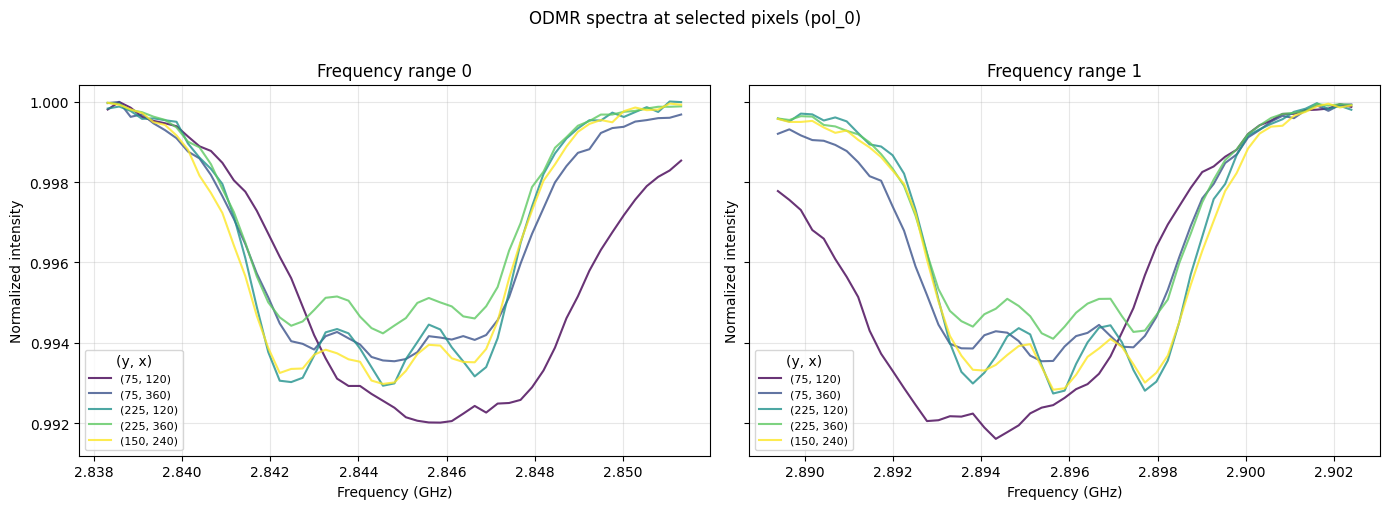

In [10]:
# Sample pixels at different locations in the binned data
ny, nx = proc.data.sizes["y"], proc.data.sizes["x"]
sample_pixels = [
    (ny // 4, nx // 4),
    (ny // 4, 3 * nx // 4),
    (3 * ny // 4, nx // 4),
    (3 * ny // 4, 3 * nx // 4),
    (ny // 2, nx // 2),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(sample_pixels)))

for i_frange in range(proc.data.sizes["freq_range"]):
    ax = axes[i_frange]
    freqs = freq_ghz[i_frange]
    for (py, px), color in zip(sample_pixels, colors, strict=False):
        spectrum = proc.data.isel(polarity=0, freq_range=i_frange, y=py, x=px).values
        ax.plot(freqs, spectrum, "-", color=color, alpha=0.8, label=f"({py}, {px})")
    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel("Normalized intensity")
    ax.set_title(f"Frequency range {i_frange}")
    ax.legend(fontsize=8, title="(y, x)")
    ax.grid(True, alpha=0.3)

plt.suptitle("ODMR spectra at selected pixels (pol_0)", y=1.01)
plt.tight_layout()
plt.show()

## 9. Dip position map (quick estimate)

As a simple estimate of the resonance frequency at each pixel, we find the frequency index
of the minimum value. This gives a rough spatial map of resonance shifts without full fitting.

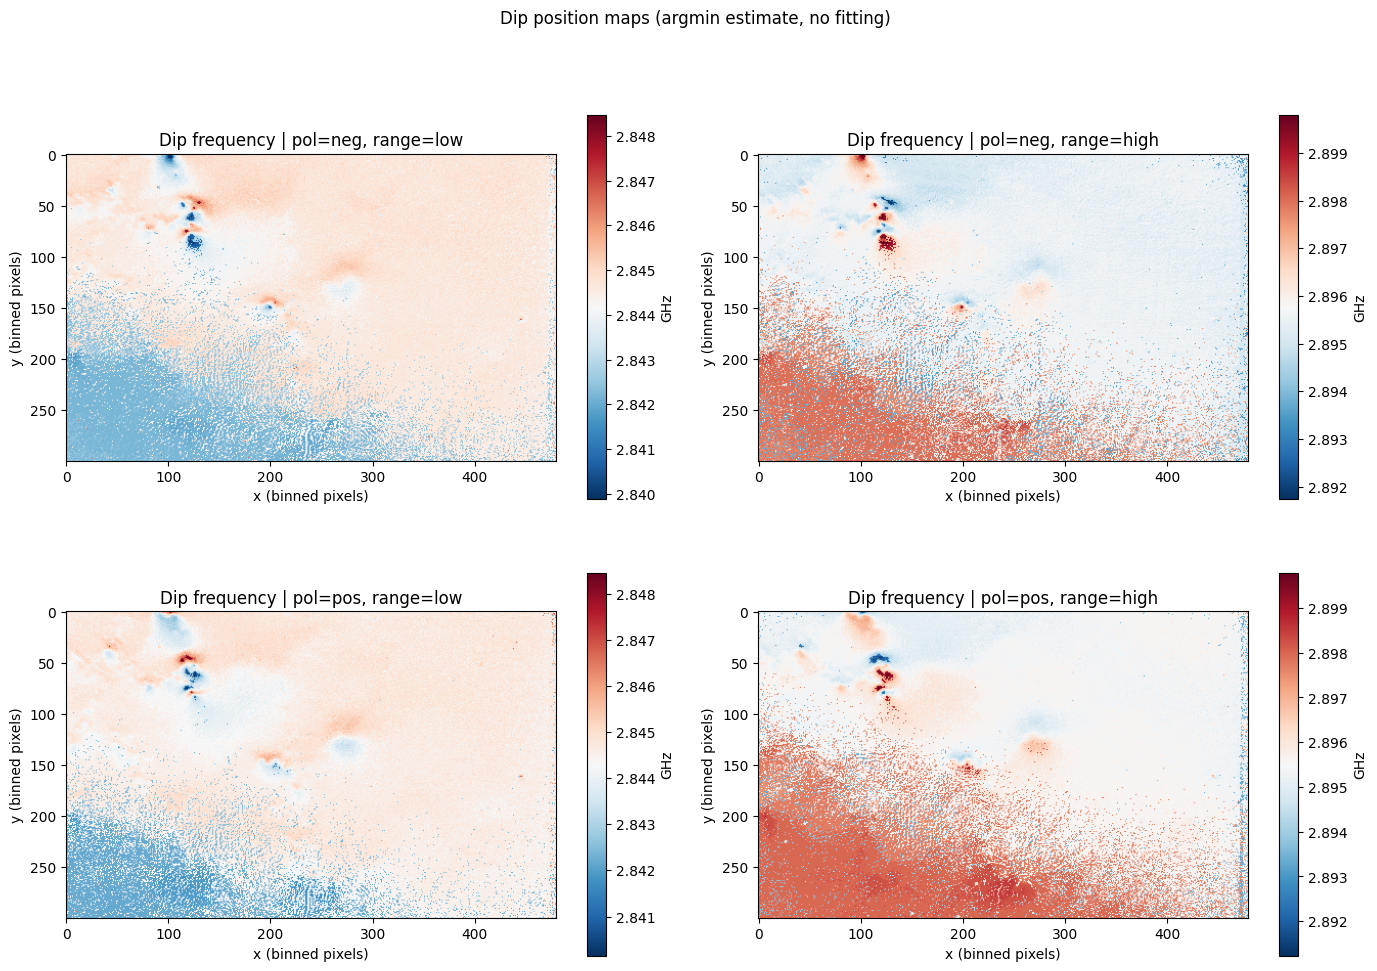

In [11]:
# Work with processed (binned + normalized) data
proc_da = proc.data
pols = list(proc_da.coords["polarity"].values)       # ['neg', 'pos']
franges = list(proc_da.coords["freq_range"].values)   # ['low', 'high']
freq_ghz_proc = proc_da.coords["freq_ghz"].values     # shape (n_frange, n_freq)

# Store dip frequencies for each (pol, frange) — reused for quick B₁₁₁ estimate below
dip_freq_maps: dict = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i_pol, pol in enumerate(pols):
    for i_frange, frange in enumerate(franges):
        ax = axes[i_pol, i_frange]
        freqs = freq_ghz_proc[i_frange]

        # Index of minimum along frequency axis → map to frequency in GHz
        min_idx = proc_da.sel(polarity=pol, freq_range=frange).argmin(dim="freq_idx").values
        dip_freq = freqs[min_idx]
        dip_freq_maps[(pol, frange)] = dip_freq

        im = ax.imshow(dip_freq, cmap="RdBu_r")
        ax.set_title(f"Dip frequency | pol={pol}, range={frange}")
        ax.set_xlabel("x (binned pixels)")
        ax.set_ylabel("y (binned pixels)")
        fig.colorbar(im, ax=ax, shrink=0.8, label="GHz")

plt.suptitle("Dip position maps (argmin estimate, no fitting)", y=1.01)
plt.tight_layout()
plt.show()

## 10. Quick B₁₁₁ estimate from dip positions

Without full spectral fitting, a rough magnetic field map is obtained directly from the
argmin dip positions above.

For each pixel the Zeeman splitting between the high- and low-frequency branches gives:

```
δB[pol] = sign[pol] × (f_high − f_low) / 2 / γ_NV    [µT]
```

where `γ_NV = GAMMA_NV = 28.024 GHz/T` and `sign = {neg: −1, pos: +1}`.

Combining the two field polarities separates remanent from induced components:
- **Remanent field**: `(δB_neg + δB_pos) / 2` — permanent magnetization
- **Induced field**: `(δB_neg − δB_pos) / 2` — paramagnetic / bias-tracking component

In [12]:
b111 = b111_from_dip_positions(proc_da)
b111_remanent_quick = b111["remanent"]
b111_induced_quick  = b111["induced"]

print(f"B₁₁₁ remanent — range: {b111_remanent_quick.min():.1f} … {b111_remanent_quick.max():.1f} µT")
print(f"B₁₁₁ induced  — range: {b111_induced_quick.min():.1f} … {b111_induced_quick.max():.1f} µT")

B₁₁₁ remanent — range: -136.8 … 141.5 µT
B₁₁₁ induced  — range: -1055.1 … -811.6 µT


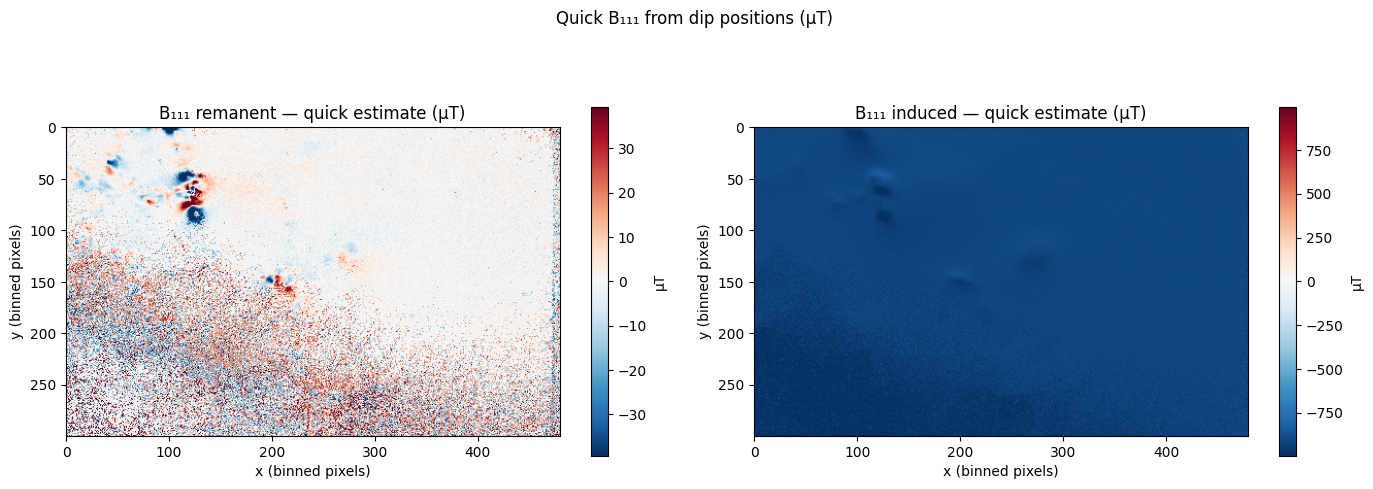

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vmax = np.percentile(np.abs(b111_remanent_quick), 99)
im0 = axes[0].imshow(b111_remanent_quick, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[0].set_title("B₁₁₁ remanent — quick estimate (µT)")
axes[0].set_xlabel("x (binned pixels)")
axes[0].set_ylabel("y (binned pixels)")
fig.colorbar(im0, ax=axes[0], shrink=0.8, label="µT")

vmax = np.percentile(np.abs(b111_induced_quick), 99)
im1 = axes[1].imshow(b111_induced_quick, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[1].set_title("B₁₁₁ induced — quick estimate (µT)")
axes[1].set_xlabel("x (binned pixels)")
axes[1].set_ylabel("y (binned pixels)")
fig.colorbar(im1, ax=axes[1], shrink=0.8, label="µT")

plt.suptitle("Quick B₁₁₁ from dip positions (µT)", y=1.01)
plt.tight_layout()
plt.show()

## 11. Full spectral fitting with FitManager

The quick estimate gives a useful first impression. For quantitative field maps,
`FitManager` fits each pixel's full ODMR spectrum to a physics-based model (`ESR14N`:
three Lorentzian dips with ¹⁴N hyperfine splitting at 2.16 MHz).

This gives accurate resonance frequencies, linewidths, contrasts, and chi² fit quality per pixel.

In [14]:
fitm = FitManager("ESR14N")
res = fitm.fit(proc_da, freq_ghz_proc)

metrics = res.get_fit_quality_metrics()
print(res)
print(f"\nConvergence rate: {metrics['convergence_rate']:.3%}")
print(f"Mean chi²:        {metrics['mean_chi2']:.2e}")
print(f"Total fit time:   {metrics['total_fit_time']:.1f} s")

2026-02-21 07:25:48.778 | INFO     | QDMpy.fitting.manager:__init__:311 - FitManager initialized with model: ESR14N
2026-02-21 07:25:53.645 | INFO     | QDMpy.fitting.manager:fit:415 - Fitting frequency range 0 from 2.838-2.851 GHz
2026-02-21 07:25:56.180 | INFO     | QDMpy.fitting.manager:fit:423 - Fit finished in 2.49 seconds
2026-02-21 07:25:56.181 | INFO     | QDMpy.fitting.manager:fit:415 - Fitting frequency range 1 from 2.889-2.902 GHz
2026-02-21 07:25:57.182 | INFO     | QDMpy.fitting.manager:fit:423 - Fit finished in 0.96 seconds
2026-02-21 07:25:57.191 | INFO     | QDMpy.fitting.result:model_post_init:87 - FitResult initialized with model: ESR14N
2026-02-21 07:25:57.200 | INFO     | QDMpy.fitting.result:get_fit_quality_metrics:527 - Fit quality metrics: mean_chi2=0.000, n_pixels=576000
parameters={'center': array([[[2.8445792, 2.8445683, 2.8445716, ..., 2.844343 , 2.8443286,
         2.8443131],
        [2.8953238, 2.8953202, 2.8953304, ..., 2.8954782, 2.895507 ,
         2.89

## 12. B₁₁₁ from full fit

`FitResult` computes B₁₁₁ from the fitted resonance centres — more accurate than the argmin
estimate since the Lorentzian fit averages over the full spectrum and is robust to noise.

2026-02-21 07:25:57.222 | INFO     | QDMpy.fitting.result:_compute_b111:419 - Computing B111 magnetic field components


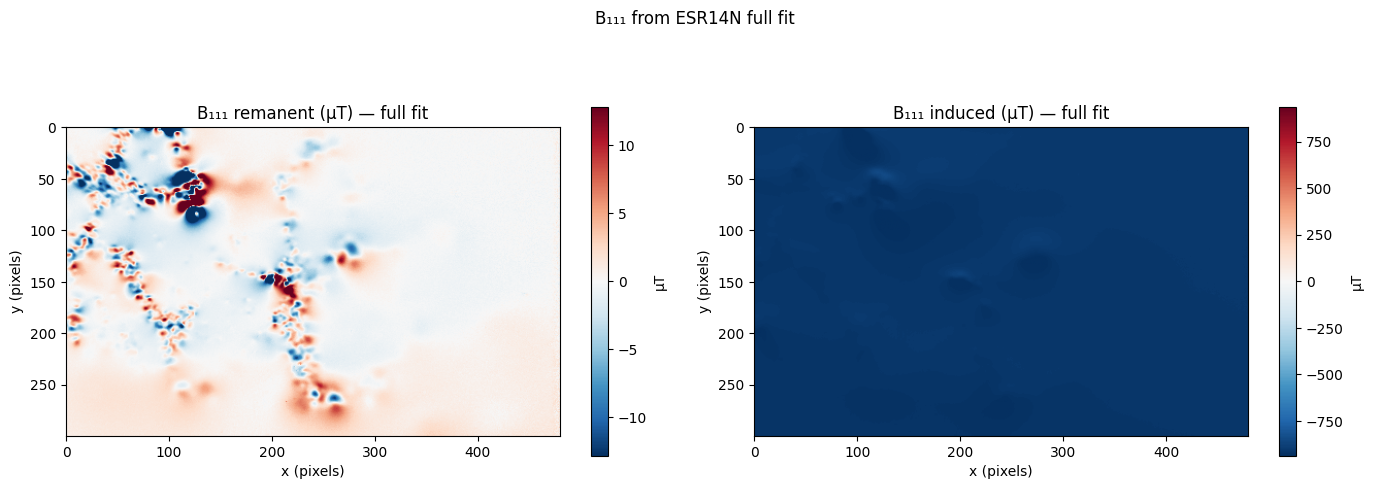

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vmax = np.percentile(np.abs(res.b111_remanent), 99)
im0 = axes[0].imshow(res.b111_remanent, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[0].set_title("B₁₁₁ remanent (µT) — full fit")
axes[0].set_xlabel("x (pixels)")
axes[0].set_ylabel("y (pixels)")
fig.colorbar(im0, ax=axes[0], shrink=0.8, label="µT")

vmax = np.percentile(np.abs(res.b111_induced), 99)
im1 = axes[1].imshow(res.b111_induced, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[1].set_title("B₁₁₁ induced (µT) — full fit")
axes[1].set_xlabel("x (pixels)")
axes[1].set_ylabel("y (pixels)")
fig.colorbar(im1, ax=axes[1], shrink=0.8, label="µT")

plt.suptitle("B₁₁₁ from ESR14N full fit", y=1.01)
plt.tight_layout()
plt.show()

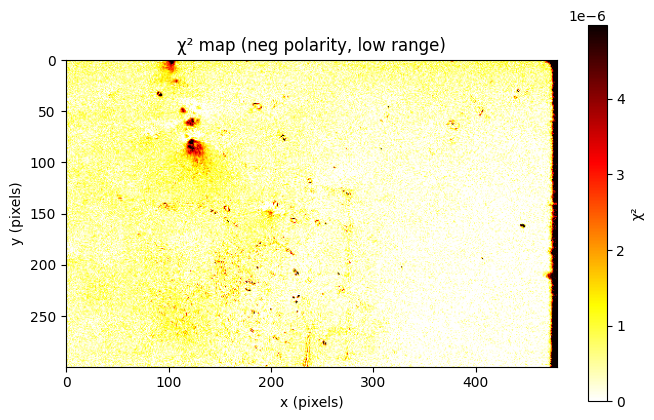

In [16]:
# Fit quality: chi² map (lower = better fit)
chi2_map = res.parameters["chi2"][0, 0].reshape(res.scan_dimensions)

fig, ax = plt.subplots(figsize=(7, 5))
vmax = np.percentile(chi2_map, 99)
im = ax.imshow(chi2_map, cmap="hot_r", vmin=0, vmax=vmax)
ax.set_title("χ² map (neg polarity, low range)")
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
fig.colorbar(im, ax=ax, shrink=0.8, label="χ²")
plt.tight_layout()
plt.show()

## 13. Summary

This notebook walked through a complete QDM analysis workflow on the MIL2_FOV1 dataset:

| Step | Tool | Key output |
|------|------|-----------|
| Load | `MatlabLoader` + `ODMRData.from_loader` | 5D xarray DataArray (pol, frange, y, x, freq) |
| Process | `ODMR` + `BinningProcessor`, `NormalizationProcessor`, `FluorescenceCorrectionProcessor` | Binned & normalised spectra |
| Quick B₁₁₁ | argmin per pixel + B₁₁₁ formula | Rough field maps without GPU fitting |
| Full fit | `FitManager("ESR14N").fit(data, freq)` | `FitResult` with all parameters |
| B₁₁₁ | `res.b111_remanent`, `res.b111_induced` | Accurate field maps in µT |

The **quick estimate** is useful for a fast sanity-check before committing to a full GPU fit.
The **full fit** gives quantitative parameters (linewidth, contrast, chi²) and more accurate field maps.

### Next steps
- `processor_tutorial.ipynb` — deep dive into the processing pipeline and fluorescence correction
- `tutorial_fitting.ipynb` — constraint management and advanced fitting options
- `tutorial_models.ipynb` — ESR14N / ESR15N / ESRSINGLE model details

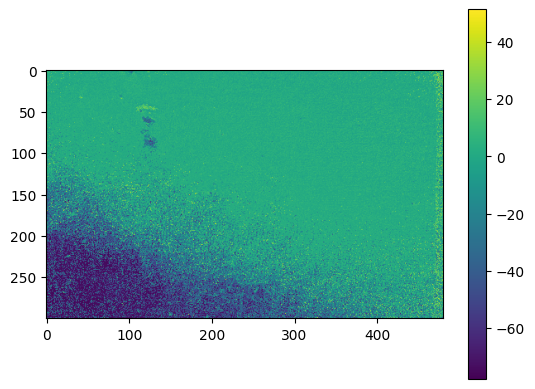

In [17]:
plt.imshow(b111_induced_quick-res.b111_induced)
plt.colorbar()

In [18]:
res.contrasts

array([[[0.00591894, 0.00592481, 0.00594212, ..., 0.003     ,
         0.003     , 0.003     ],
        [0.00607157, 0.00608425, 0.00610832, ..., 0.003     ,
         0.003     , 0.003     ]],

       [[0.00605584, 0.00599068, 0.00603502, ..., 0.003     ,
         0.003     , 0.003     ],
        [0.00619358, 0.00618151, 0.0061329 , ..., 0.003     ,
         0.003     , 0.003     ]]], shape=(2, 2, 144000), dtype=float32)